**Step 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load Dataset**

In [ ]:
data = pd.read_csv("Final_Marks_Data.csv")

print(data.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3                  3            

**Step 3: Data Preprocessing**

In [ ]:
data = data.dropna()

data.rename(columns={
    'Attendance (%)': 'Attendance',
    'Daily Study Hours': 'Study_Hours',
    'Assignment Score (out of 10)': 'Assignments',
    'Internal Test 1 (out of 40)': 'Internal_Test_1',
    'Internal Test 2 (out of 40)': 'Internal_Test_2',
    'Final Exam Marks (out of 100)': 'Final_Marks'
}, inplace=True)

data['Final_Result'] = data['Final_Marks'].apply(
    lambda x: 1 if x >= 50 else 0
)

**Step 4: Feature Selection**

In [ ]:
X = data[['Study_Hours',
          'Attendance',
          'Internal_Test_1',
          'Internal_Test_2',
          'Assignments']]

y = data['Final_Result']

**Step 5: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Step 6: Apply ML Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

**Step 7: Train & Evaluate Models**

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print("\n", name)
    print("Accuracy:", acc)


 Logistic Regression
Accuracy: 0.9475

 Decision Tree
Accuracy: 0.905

 Naive Bayes
Accuracy: 0.9375

 SVM
Accuracy: 0.93


In [ ]:
best_model_name = max(results, key=results.get)
print("\nBest Model is:", best_model_name, "with accuracy:", results[best_model_name])


Best Model is: Logistic Regression with accuracy: 0.9475


**Step 8:Data Visualization[Graphs]**

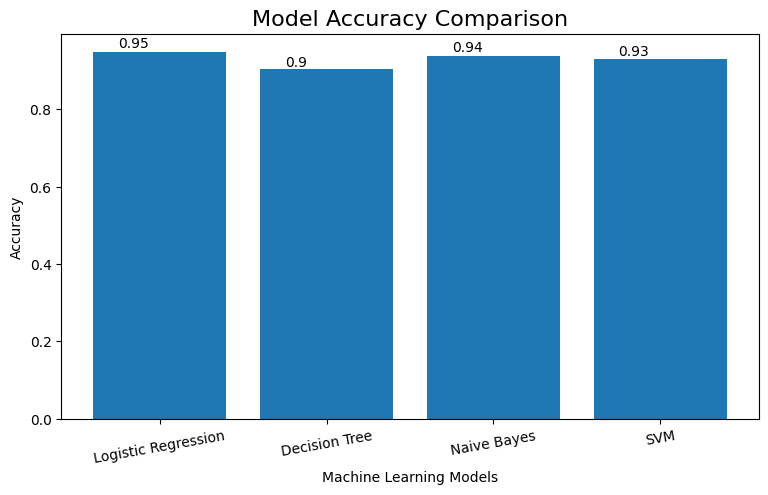

In [ ]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

# show values on bars
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(
        bar.get_x() + 0.15,
        yval + 0.01,
        yval
    )

plt.xticks(rotation=10)

plt.show()

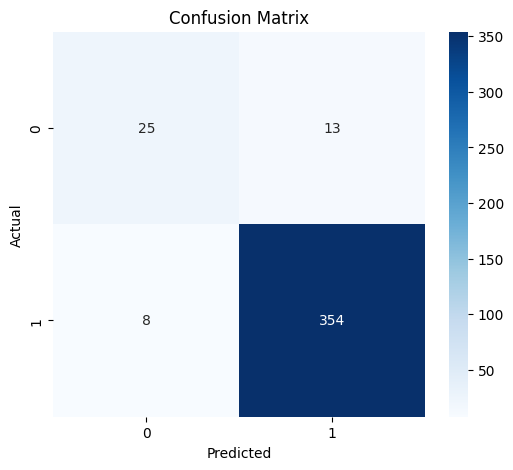

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = models[max(results, key=results.get)]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

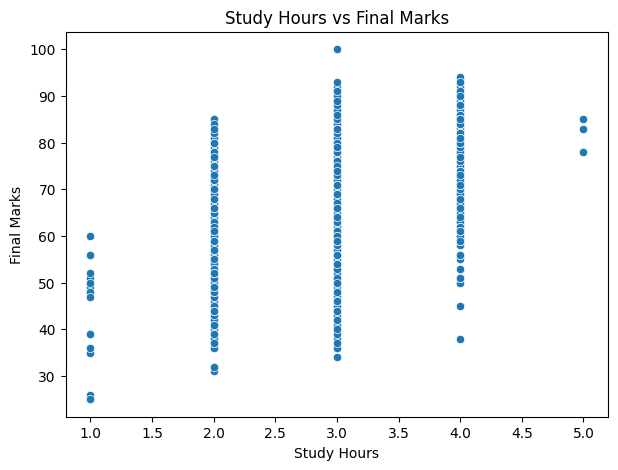

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=data['Study_Hours'],
    y=data['Final_Marks']
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")

plt.show()

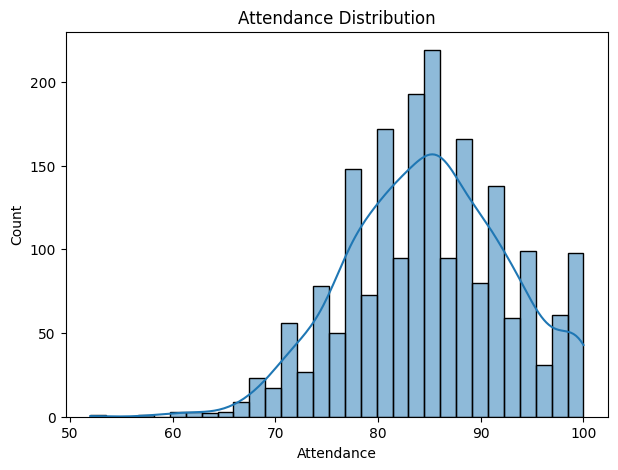

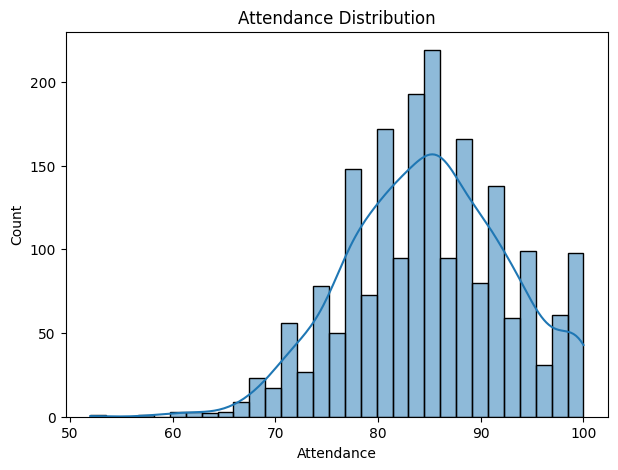

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(
    data['Attendance'],
    kde=True
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")

plt.show()

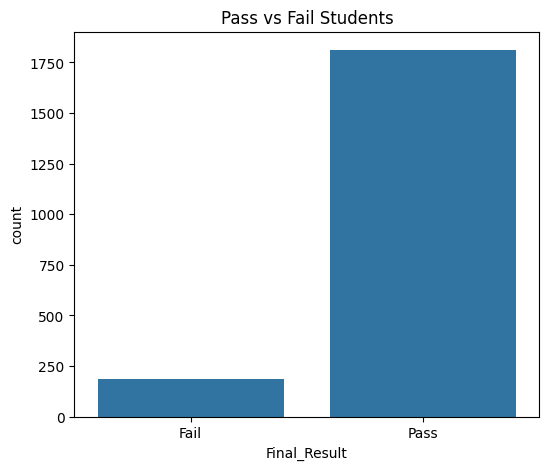

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Final_Result',
    data=data
)

plt.title("Pass vs Fail Students")
plt.xticks([0,1], ['Fail','Pass'])

plt.show()

**Step 9: Best Model Selection**

In [ ]:
best_model_name = max(results, key=results.get)

print(
    "Best Model:",
    best_model_name
)

Best Model: Logistic Regression


**Step 10: Manual Prediction**

In [ ]:
print("Enter Student Details")

sh = float(input("Study Hours: "))
att = float(input("Attendance: "))
it1 = float(input("Internal Test 1: "))
it2 = float(input("Internal Test 2: "))
asg = float(input("Assignments: "))

new_student = pd.DataFrame({
    'Study_Hours':[sh],
    'Attendance':[att],
    'Internal_Test_1':[it1],
    'Internal_Test_2':[it2],
    'Assignments':[asg]
})

result = best_model.predict(new_student)

if result[0] == 1:
    print("Student will Pass")
else:
    print("Student will Fail")

Enter Student Details
Study Hours: 6
Attendance: 89
Internal Test 1: 23
Internal Test 2: 25
Assignments: 67
Student will Pass


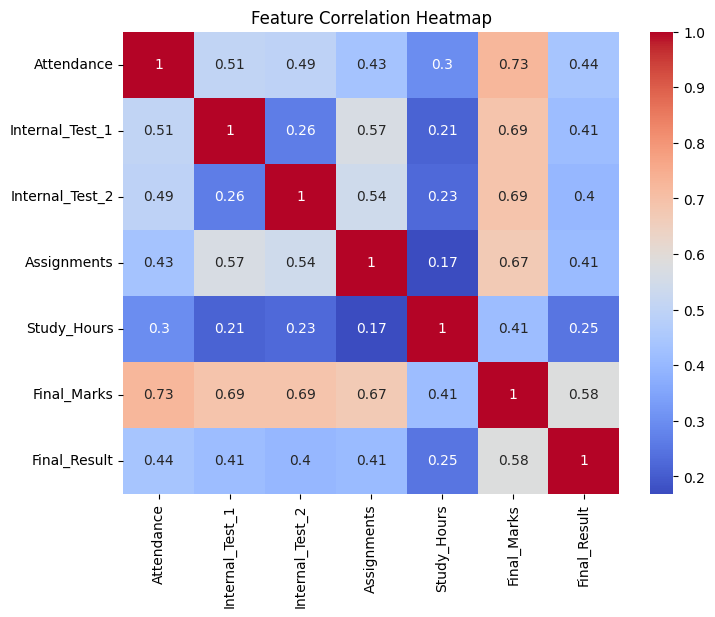

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()